In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RUNS = [
    {
        'label': 'foraging only',
        'path': Path('../../../checkpoints/pretrain_foraging/_reward_rates/step_00'),
        'color': 'steelblue',
    },
    {
        'label': 'integration → foraging (step 02)',
        'path': Path('../../../checkpoints/pretrain_integration_to_foraging/_reward_rates/step_02'),
        'color': 'darkorange',
    },
]

def load_reward_rates(path):
    """Load per-session mean reward rate. Each file = one session, shape (n_updates,)."""
    files = sorted(path.iterdir())
    means = []
    for f in files:
        with open(f, 'rb') as fh:
            arr = np.load(fh)
        means.append(arr.mean())
    return np.array(means)

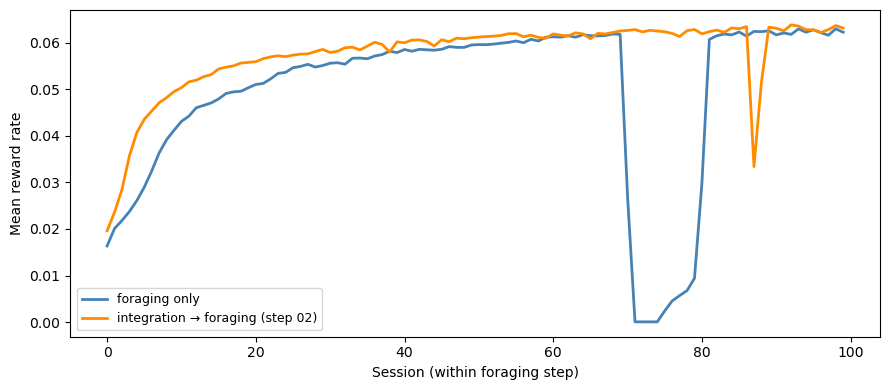

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

for run in RUNS:
    rates = load_reward_rates(run['path'])
    ax.plot(rates, color=run['color'], linewidth=2, label=run['label'])

ax.set_xlabel('Session (within foraging step)')
ax.set_ylabel('Mean reward rate')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()